# 策略二：横截面动量

## 核心思路

过去表现好的股票（12-1个月），往往会继续跑赢市场（Jegadeesh & Titman 1993年发现的动量效应）。
跳过最近1个月是为了规避**短期反转**效应。

## 实现步骤

1. **股票池**：约100只 S&P500 大盘股，覆盖各行业
2. **信号构建**：每月计算每只股票 `[t-12月, t-1月]` 区间的累计收益率
3. **组合构建**：按信号排名，做多前20%（赢家）、做空后20%（输家），等权
4. **再平衡**：月末收盘价执行，月度再平衡
5. **成本**：每腿 10 bps 手续费

## 研究问题

- 动量因子的样本外表现如何？
- 因子衰减有多快（持有期分析）？
- 与 SPY 买入持有相比如何？

## 数据

- 来源：`yfinance` 月线，2010–2024
- 股票池：科技、金融、医疗、消费、能源、工业等各板块龙头股

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)

In [2]:
# ── 参数设置 ──────────────────────────────────────────────
START            = '2010-01-01'
END              = '2024-12-31'
LOOKBACK_MONTHS  = 12    # 动量回溯期（月）
SKIP_MONTHS      = 1     # 跳过最近1个月（规避短期反转）
QUINTILE         = 0.2   # 多头/空头各取前/后 20%
TRANSACTION_COST = 0.001 # 单腿手续费（10 bps）

# 股票池：约100只 S&P500 大盘股，覆盖多个行业板块
UNIVERSE = [
    # 科技
    'AAPL','MSFT','GOOGL','META','NVDA','AMZN','TSLA','ORCL','IBM','INTC',
    'QCOM','TXN','AMD','AMAT','MU',
    # 金融
    'JPM','BAC','GS','MS','WFC','C','BLK','AXP','USB','PNC',
    # 医疗健康
    'JNJ','UNH','PFE','ABBV','MRK','LLY','BMY','AMGN','MDT','ABT',
    # 消费必需品
    'KO','PEP','PG','WMT','COST','MCD','NKE','SBUX','YUM','CL',
    # 能源
    'XOM','CVX','COP','EOG','SLB','PSX','VLO','MPC','HES','OXY',
    # 工业
    'BA','CAT','GE','HON','MMM','UPS','RTX','LMT','DE','EMR',
    # 原材料与公用事业
    'LIN','APD','NEM','FCX','NEE','DUK','SO','D','EXC','AEP',
    # 基准指数
    'SPY'
]

In [3]:
# ── 下载月线数据 ───────────────────────────────────────────
raw = yf.download(UNIVERSE, start=START, end=END,
                  auto_adjust=True, progress=False, interval='1mo')
px_monthly  = raw['Close'].dropna(how='all')
px_monthly  = px_monthly.loc[:, px_monthly.notna().sum() > 100]
monthly_ret = px_monthly.pct_change()
print(f'股票池：{len(px_monthly.columns)-1} 只股票 + SPY  |  {len(px_monthly)} 个月')

HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: HES"}}}


$HES: possibly delisted; no timezone found


$OXY: possibly delisted; no price data found  (1mo 2010-01-01 -> 2024-12-31)



2 Failed downloads:


['HES']: possibly delisted; no timezone found


['OXY']: possibly delisted; no price data found  (1mo 2010-01-01 -> 2024-12-31)


股票池：73 只股票 + SPY  |  180 个月


In [4]:
# ── 构建动量信号 ───────────────────────────────────────────
# 动量 = [t-12月, t-1月] 区间的累计收益率（跳过最近1个月）
def momentum_signal(px, lookback=LOOKBACK_MONTHS, skip=SKIP_MONTHS):
    """12-1 月动量信号：t-skip 对比 t-lookback 的收益率。"""
    lag_long  = px.shift(skip)      # t-1 月的价格
    lag_short = px.shift(lookback)  # t-12 月的价格
    return lag_long / lag_short - 1

signal = momentum_signal(px_monthly)

# 从信号中排除 SPY（基准，不参与排名）
stock_cols   = [c for c in signal.columns if c != 'SPY']
stock_signal = signal[stock_cols]

In [5]:
# ── 回测：月度再平衡 ──────────────────────────────────────
port_returns = []
dates = []

for i in range(LOOKBACK_MONTHS + 1, len(px_monthly)):
    date    = px_monthly.index[i]
    sig_row = stock_signal.iloc[i].dropna()
    if len(sig_row) < 20:
        continue

    ranked = sig_row.rank(pct=True)
    longs  = ranked[ranked >= 1 - QUINTILE].index.tolist()  # 赢家组（前20%）
    shorts = ranked[ranked <= QUINTILE].index.tolist()       # 输家组（后20%）

    # 下月实际收益（月末收盘执行，无前视偏差）
    fwd_ret = monthly_ret[stock_cols].iloc[i]

    long_ret  = fwd_ret[longs].mean()
    short_ret = fwd_ret[shorts].mean()

    gross_ret = (long_ret - short_ret) / 2  # 美元中性：多空各半
    tc_cost   = TRANSACTION_COST * 2        # 估算换手成本
    net_ret   = gross_ret - tc_cost

    port_returns.append(net_ret)
    dates.append(date)

port_ret = pd.Series(port_returns, index=dates, name='动量策略')
spy_ret  = monthly_ret['SPY'].reindex(dates)

print(f"回测区间：{dates[0].date()} 至 {dates[-1].date()}")
print(f"共 {len(dates)} 个月")

回测区间：2011-02-01 至 2024-12-01
共 167 个月


In [6]:
# ── 绩效统计 ──────────────────────────────────────────────
def stats(ret, label=''):
    ann_ret = ret.mean() * 12
    ann_vol = ret.std() * np.sqrt(12)
    sharpe  = ann_ret / ann_vol if ann_vol != 0 else 0
    cum     = (1 + ret).cumprod()
    max_dd  = ((cum - cum.cummax()) / cum.cummax()).min()
    calmar  = ann_ret / abs(max_dd) if max_dd != 0 else 0
    hit     = (ret > 0).mean()
    print(f"{'='*42}\n  {label}\n{'='*42}")
    print(f"  年化收益率  : {ann_ret*100:.2f}%")
    print(f"  年化波动率  : {ann_vol*100:.2f}%")
    print(f"  夏普比率    : {sharpe:.3f}")
    print(f"  最大回撤    : {max_dd*100:.2f}%")
    print(f"  卡玛比率    : {calmar:.3f}")
    print(f"  胜率        : {hit*100:.1f}%")
    return cum

mom_cum = stats(port_ret, '横截面动量（多空）')
spy_cum = stats(spy_ret,  'SPY 买入持有')

  横截面动量（多空）
  年化收益率  : -0.59%
  年化波动率  : 10.28%
  夏普比率    : -0.057
  最大回撤    : -25.78%
  卡玛比率    : -0.023
  胜率        : 51.5%
  SPY 买入持有
  年化收益率  : 13.84%
  年化波动率  : 14.60%
  夏普比率    : 0.948
  最大回撤    : -23.97%
  卡玛比率    : 0.577
  胜率        : 67.1%


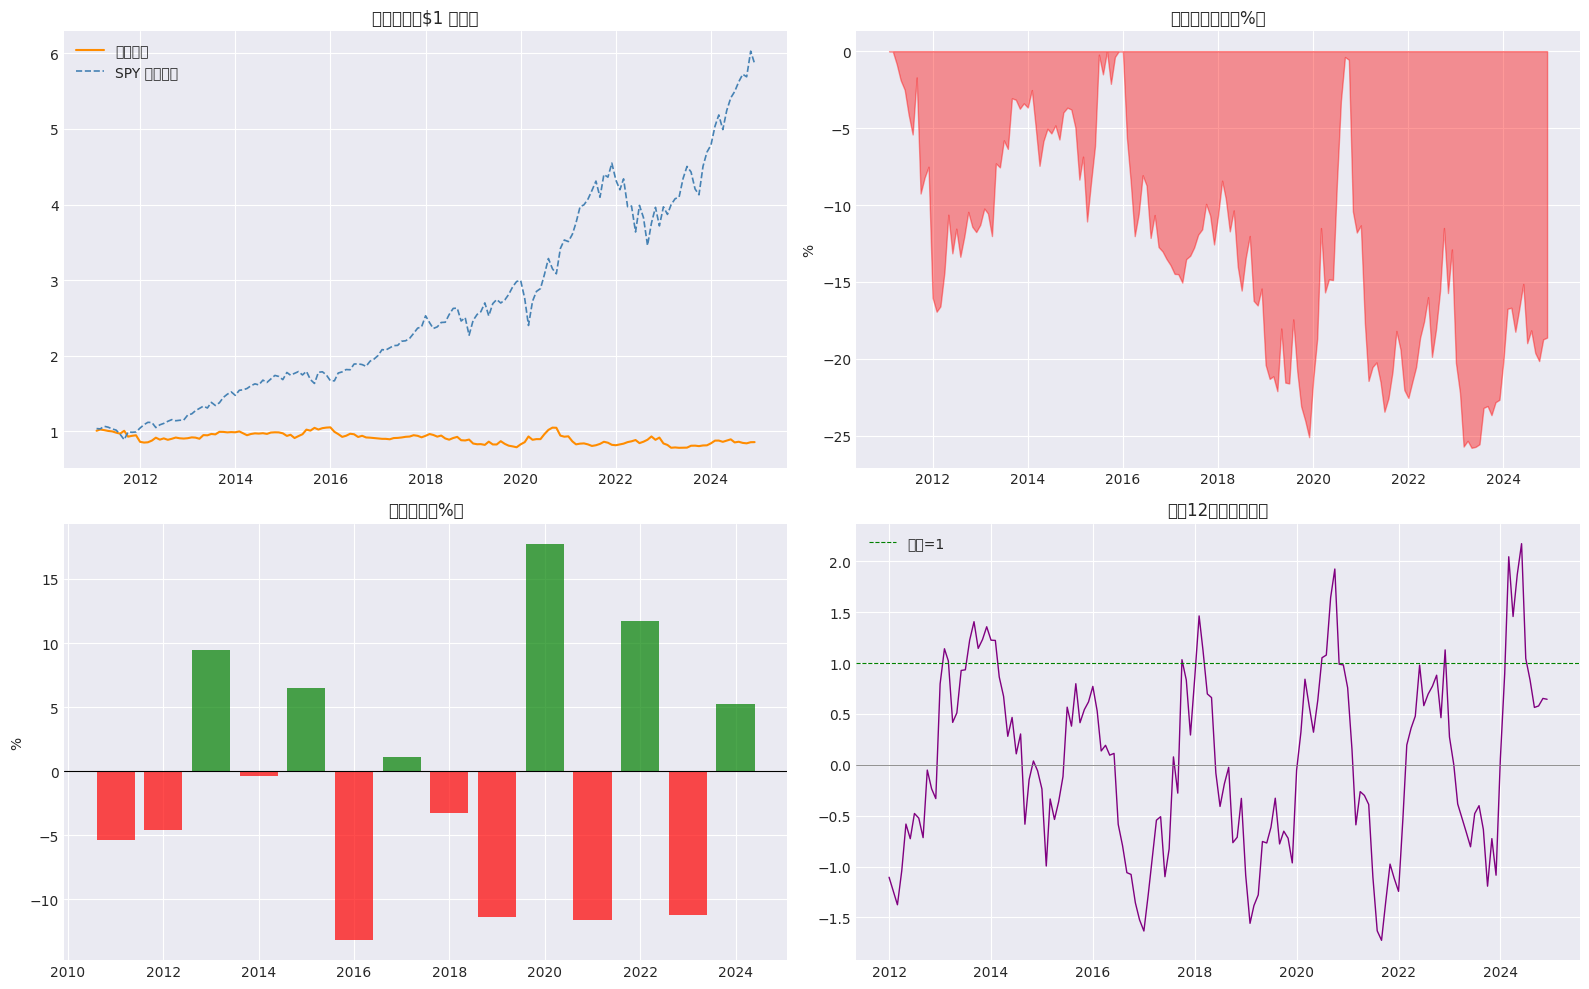

In [7]:
# ── 可视化：净值曲线、回撤、年度收益、滚动夏普 ─────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. 净值曲线对比
axes[0,0].plot(mom_cum.index, mom_cum.values, label='动量多空', color='darkorange', lw=1.5)
axes[0,0].plot(spy_cum.index, spy_cum.values, label='SPY 买入持有', color='steelblue', lw=1.2, ls='--')
axes[0,0].set_title('净值曲线（$1 起始）', fontsize=12)
axes[0,0].legend()

# 2. 动量策略回撤
mom_dd = (mom_cum - mom_cum.cummax()) / mom_cum.cummax()
axes[0,1].fill_between(mom_dd.index, mom_dd.values * 100, color='red', alpha=0.4)
axes[0,1].set_title('动量策略回撤（%）', fontsize=12)
axes[0,1].set_ylabel('%')

# 3. 年度收益柱状图
ann_rets = port_ret.resample('YE').apply(lambda x: (1+x).prod() - 1)
colors   = ['green' if r > 0 else 'red' for r in ann_rets.values]
axes[1,0].bar(ann_rets.index.year, ann_rets.values * 100, color=colors, alpha=0.7)
axes[1,0].axhline(0, color='black', lw=0.8)
axes[1,0].set_title('年度收益（%）', fontsize=12)
axes[1,0].set_ylabel('%')

# 4. 滚动12个月夏普比率
roll_sharpe = (port_ret.rolling(12).mean() * 12) / (port_ret.rolling(12).std() * np.sqrt(12))
axes[1,1].plot(roll_sharpe.index, roll_sharpe.values, color='purple', lw=1)
axes[1,1].axhline(0, color='grey', lw=0.6)
axes[1,1].axhline(1, color='green', ls='--', lw=0.8, label='夏普=1')
axes[1,1].set_title('滚动12个月夏普比率', fontsize=12)
axes[1,1].legend()

plt.tight_layout()
plt.savefig('../data/momentum_results.png', dpi=120, bbox_inches='tight')
plt.show()

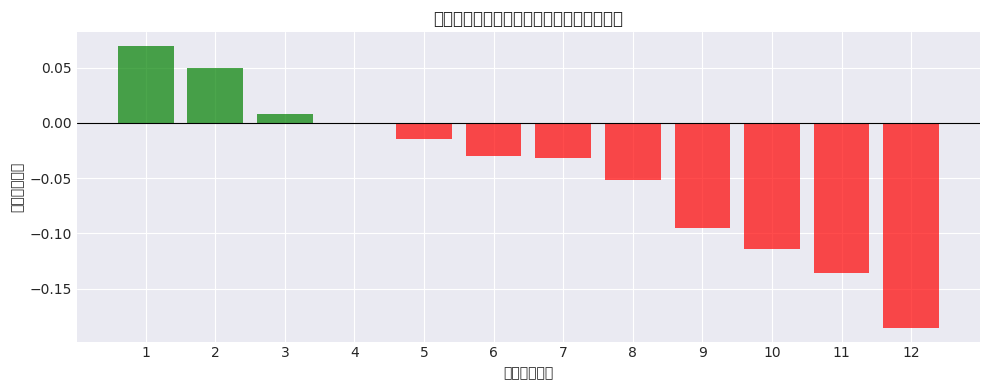

In [8]:
# ── 因子衰减分析：动量持续多久？ ─────────────────────────────
# 研究不同持有期下，动量因子的夏普比率如何衰减
hold_periods = range(1, 13)
hold_sharpes = []

for h in hold_periods:
    rets = []
    for i in range(LOOKBACK_MONTHS + 1, len(px_monthly) - h):
        sig_row = stock_signal.iloc[i].dropna()
        if len(sig_row) < 20:
            continue
        ranked = sig_row.rank(pct=True)
        longs  = ranked[ranked >= 1 - QUINTILE].index
        shorts = ranked[ranked <= QUINTILE].index
        # h个月后的实际收益
        fwd_h = (px_monthly[stock_cols].iloc[i+h] / px_monthly[stock_cols].iloc[i] - 1)
        r = (fwd_h[longs].mean() - fwd_h[shorts].mean()) / 2
        rets.append(r)
    r_series = pd.Series(rets)
    sh = r_series.mean() / r_series.std() * np.sqrt(12 / h) if r_series.std() != 0 else 0
    hold_sharpes.append(sh)

plt.figure(figsize=(10, 4))
plt.bar(hold_periods, hold_sharpes,
        color=['green' if s > 0 else 'red' for s in hold_sharpes], alpha=0.7)
plt.axhline(0, color='black', lw=0.8)
plt.xlabel('持有期（月）')
plt.ylabel('年化夏普比率')
plt.title('动量因子衰减分析：不同持有期的夏普比率')
plt.xticks(list(hold_periods))
plt.tight_layout()
plt.show()